# 04 — Inference-time стратегии

**Этап 4 задания на ВКР:** измерение inference-time compute scaling.

Для каждой зафиксированной модели генерируются n=32 решения на каждую тестовую задачу (однократно, с кэшированием). К одному набору генераций применяются три стратегии агрегации:
1. **Голосование большинством** (majority voting)
2. **Best-of-N** с PRM-верификатором (Qwen2.5-Math-PRM-7B)
3. **Взвешенное голосование** (weighted voting с PRM scores)

Точность измеряется при n = 1, 4, 8, 16, 32.

**Оптимизации v2:**
- max_tokens раздельно: GSM8K=2048, MATH=4096
- PRM batching (несколько решений за forward pass)
- seed=42 для воспроизводимости
- log_score вместо prod_score для ranking
- make_step_rewards через bool mask (чистая реализация)
- try/finally для GPU cleanup

## Шаг 0. Зависимости, GPU, пути, импорты

In [ ]:
!pip install -q torch transformers peft datasets scipy vllm

import torch, os, json, sys, time, re, logging, gc
import numpy as np

assert torch.cuda.is_available(), 'GPU не найден'
print(f'GPU: {torch.cuda.get_device_name(0)}, '
      f'{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

from google.colab import drive
drive.mount('/content/drive')

# Пути (те же, что в 00–03)
MODEL_ROOT    = '/content/drive/MyDrive/vkr_models'
DATA_ROOT     = '/content/drive/MyDrive/vkr_data'
RESULTS_ROOT  = '/content/drive/MyDrive/vkr_results'
SUBSETS_DIR   = f'{DATA_ROOT}/subsets'
BASE_MODEL    = f'{MODEL_ROOT}/Qwen2.5-1.5B'

# Из предыдущих ноутбуков
SFT_MODELS    = f'{MODEL_ROOT}/sft'
MERGED_DIR    = f'{MODEL_ROOT}/sft_merged'
GRPO_MODELS   = f'{MODEL_ROOT}/grpo'
PRM_MODEL     = f'{MODEL_ROOT}/Qwen2.5-Math-PRM-7B'

# Новые пути
INFER_RESULTS = f'{RESULTS_ROOT}/inference'
INFER_GENS    = f'{INFER_RESULTS}/generations'
INFER_SCORES  = f'{INFER_RESULTS}/prm_scores'
for d in [INFER_RESULTS, INFER_GENS, INFER_SCORES]:
    os.makedirs(d, exist_ok=True)

assert os.path.exists(BASE_MODEL), f'Модель не найдена: {BASE_MODEL}'
assert os.path.exists(PRM_MODEL), f'PRM не найден: {PRM_MODEL}'

# parsing.py из 00_setup
sys.path.insert(0, DATA_ROOT)
import parsing

# Attention backend
try:
    import flash_attn; ATTN_IMPL = 'flash_attention_2'
except ImportError:
    ATTN_IMPL = 'eager'

print(f'Базовая модель: {BASE_MODEL}')
print(f'PRM:            {PRM_MODEL}')
print(f'Attention:      {ATTN_IMPL}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.7/267.7 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 97.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.

## Шаг 1. Тестовые данные, конфигурация, утилиты

In [ ]:
from transformers import AutoTokenizer
from datasets import load_dataset

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
print(f'Токенизатор: vocab={tokenizer.vocab_size}, EOS={tokenizer.eos_token!r}')

# Тестовые наборы
ds_gsm8k = load_dataset('openai/gsm8k', 'main', split='test')
ds_math500 = load_dataset('HuggingFaceH4/MATH-500', split='test')
assert len(ds_gsm8k) == 1319 and len(ds_math500) == 500
print(f'GSM8K: {len(ds_gsm8k)}, MATH-500: {len(ds_math500)}')

GSM8K_PROBLEMS = [ex['question'] for ex in ds_gsm8k]
GSM8K_GOLDS    = [parsing.extract_answer_gsm8k(ex['answer']) for ex in ds_gsm8k]
MATH_PROBLEMS  = [ex['problem'] for ex in ds_math500]
MATH_GOLDS     = [ex['answer'] for ex in ds_math500]

PROMPT_SUFFIX = '\n\nPlease reason step by step, and put your final answer within \\boxed{}.'
STOP_TOKENS   = ['<|im_end|>', '<|endoftext|>']

# Конфигурация inference
N_SAMPLES   = 32
TEMPERATURE = 1
SEED        = 42
N_VALUES    = [1, 4, 8, 16, 32]

# max_tokens раздельно: GSM8K короче, MATH длиннее
MAX_TOKENS = {'gsm8k': 2048, 'math500': 4096}

# Утилиты: единый парсер и компаратор (протокол проекта)
# Парсер: только \boxed{} для обоих бенчмарков (как в 02_sft, 03_grpo)
# Компаратор: is_correct_gsm8k (числовой) для GSM8K, is_equiv (символьный) для MATH

def extract_pred(resp: str) -> str | None:
    """Извлечение ответа: \\boxed{} для обоих бенчмарков (протокол проекта)."""
    return parsing.extract_answer_math(resp)


def is_correct(pred: str | None, gold: str, benchmark: str) -> bool:
    """Проверка ответа: числовое сравнение для GSM8K, символьное для MATH."""
    if pred is None:
        return False
    if benchmark == 'gsm8k':
        return parsing.is_correct_gsm8k(pred, gold)
    return parsing.is_equiv(pred, gold)


def answers_equivalent(a: str, b: str, benchmark: str) -> bool:
    """Проверка эквивалентности двух ответов."""
    if benchmark == 'gsm8k':
        return parsing.is_correct_gsm8k(a, b)
    return parsing.is_equiv(a, b)


# Модели для тестирования
MODELS_TO_EVAL = {}

sft_adapter = f'{SFT_MODELS}/c2048_v500_s42'
if os.path.exists(sft_adapter):
    MODELS_TO_EVAL['sft_c2048_v500_s42'] = {
        'type': 'sft_lora',
        'base': BASE_MODEL,
        'adapter': sft_adapter,
    }
    print(f'SFT адаптер: {sft_adapter} ✓')

# ═══ NORM ═══ GRPO чекпоинты (LoRA поверх merged SFT)
# for step in [50, 100]:
#     ckpt = f'{GRPO_MODELS}/v500_smoke/checkpoint-{step}'
#     if os.path.exists(ckpt):
#         MODELS_TO_EVAL[f'grpo_v500_ckpt{step}'] = {
#             'type': 'grpo_lora',
#             'base': f'{MERGED_DIR}/v500_best',
#             'adapter': ckpt,
#         }

print(f'\nМоделей для eval: {len(MODELS_TO_EVAL)}')
for name, cfg in MODELS_TO_EVAL.items():
    print(f'  {name}: {cfg["type"]}')

Токенизатор: vocab=151643, EOS='<|endoftext|>'


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/412 [00:00<?, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

GSM8K: 1319, MATH-500: 500
SFT адаптер: /content/drive/MyDrive/vkr_models/sft/c2048_v500_s42 ✓

Моделей для eval: 1
  sft_c2048_v500_s42: sft_lora


## Шаг 2. Генерация n=32 решений (vLLM)

**Оптимизация v2:** max_tokens раздельно по бенчмарку (GSM8K=2048, MATH=4096).
seed=42 для воспроизводимости. Кэш с расширенной мета.

In [ ]:
from vllm import LLM, SamplingParams
from vllm.lora.request import LoRARequest

_lora_id = 0


def _build_prompts(problems: list[str]) -> list[str]:
    return [
        tokenizer.apply_chat_template(
            [{'role': 'user', 'content': p + PROMPT_SUFFIX}],
            tokenize=False, add_generation_prompt=True)
        for p in problems
    ]


def _cache_meta(model_name: str, benchmark: str) -> dict:
    """Расширенная мета для инвалидации кэша."""
    cfg = MODELS_TO_EVAL.get(model_name, {})
    return {
        'model_name': model_name,
        'base_path': cfg.get('base', ''),
        'adapter_path': cfg.get('adapter', ''),
        'temperature': TEMPERATURE,
        'seed': SEED,
        'n_samples': N_SAMPLES,
        'max_tokens': MAX_TOKENS[benchmark],
        'prompt_suffix': PROMPT_SUFFIX,
        'stop': STOP_TOKENS,
    }


def _is_cache_valid(cached: dict, meta: dict, n_problems: int) -> bool:
    if not isinstance(cached, dict):
        return False
    saved = cached.get('meta', {})
    if any(saved.get(k) != v for k, v in meta.items()):
        return False
    gens = cached.get('generations', [])
    return len(gens) == n_problems and all(len(g) == N_SAMPLES for g in gens)


def generate_n_cached(engine, model_name: str, benchmark: str,
                      problems: list[str], lora_path: str | None) -> list[list[str]]:
    """Генерация n решений на задачу с кэшем.
    Возвращает: list[list[str]] — [n_problems][n_samples].
    """
    global _lora_id
    cache_path = f'{INFER_GENS}/{model_name}_{benchmark}_n{N_SAMPLES}.json'
    meta = _cache_meta(model_name, benchmark)

    if os.path.exists(cache_path):
        with open(cache_path) as f:
            cached = json.load(f)
        if _is_cache_valid(cached, meta, len(problems)):
            print(f'  [{benchmark}] кэш: {len(cached["generations"])} задач × {N_SAMPLES}')
            return cached['generations']
        print(f'  [{benchmark}] кэш невалиден, перегенерируем')

    # SamplingParams с max_tokens по бенчмарку
    sampling = SamplingParams(
        temperature=TEMPERATURE,
        max_tokens=MAX_TOKENS[benchmark],
        n=N_SAMPLES,
        seed=SEED,
        stop=STOP_TOKENS,
    )

    prompts = _build_prompts(problems)

    if lora_path is not None:
        _lora_id += 1
        lora_req = LoRARequest(model_name, _lora_id, lora_path)
        outputs = engine.generate(prompts, sampling, lora_request=lora_req)
    else:
        outputs = engine.generate(prompts, sampling)

    generations = [[o.text for o in out.outputs] for out in outputs]

    with open(cache_path, 'w') as f:
        json.dump({'meta': meta, 'generations': generations}, f, ensure_ascii=False)
    print(f'  [{benchmark}] сгенерировано: {len(generations)} задач × {N_SAMPLES}')
    return generations


print('Функции генерации определены ✓')

Функции генерации определены ✓


### 2.1 Генерация для всех моделей

In [5]:
from collections import defaultdict

groups = defaultdict(list)
for name, cfg in MODELS_TO_EVAL.items():
    groups[cfg['base']].append((name, cfg))

all_generations = {}  # {model_name: {'gsm8k': [...], 'math500': [...]}}

for base_path, models in groups.items():
    print(f'\n=== Base: {os.path.basename(base_path)} ===')

    has_lora = any(cfg.get('adapter') for _, cfg in models)
    engine = LLM(
        model=base_path, dtype='bfloat16',
        enable_lora=has_lora, max_lora_rank=64 if has_lora else None,
        max_model_len=8192, gpu_memory_utilization=0.9,
    )

    try:
        for name, cfg in models:
            print(f'\n  Модель: {name}')
            adapter = cfg.get('adapter')
            t0 = time.time()

            gsm_gens = generate_n_cached(engine, name, 'gsm8k', GSM8K_PROBLEMS, adapter)
            math_gens = generate_n_cached(engine, name, 'math500', MATH_PROBLEMS, adapter)

            all_generations[name] = {'gsm8k': gsm_gens, 'math500': math_gens}
            print(f'  Время: {(time.time() - t0)/60:.1f} мин')
    finally:
        del engine
        gc.collect()
        torch.cuda.empty_cache()
        print('GPU освобожден ✓')

print(f'\nГенерации готовы для {len(all_generations)} моделей ✓')


=== Base: Qwen2.5-1.5B ===
INFO 04-15 16:30:41 [utils.py:233] non-default args: {'dtype': 'bfloat16', 'max_model_len': 8192, 'disable_log_stats': True, 'enable_lora': True, 'max_lora_rank': 64, 'model': '/content/drive/MyDrive/vkr_models/Qwen2.5-1.5B'}
INFO 04-15 16:31:04 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 04-15 16:31:04 [model.py:1678] Using max model len 8192
INFO 04-15 16:31:04 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-15 16:31:04 [vllm.py:790] Asynchronous scheduling is enabled.
WARNING 04-15 16:31:05 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized

  Модель: sft_c2048_v500_s42


Rendering prompts:   0%|          | 0/1319 [00:00<?, ?it/s]

WARNING 04-15 16:33:21 [input_processor.py:149] vLLM has deprecated support for supporting different tokenizers for different LoRAs. By default, vLLM uses base model's tokenizer. If you are using a LoRA with its own tokenizer, consider specifying `--tokenizer [lora_path]` to use the LoRA tokenizer.


Processed prompts:   0%|          | 0/42208 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/…

  [gsm8k] сгенерировано: 1319 задач × 32


Rendering prompts:   0%|          | 0/500 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16000 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/…

  [math500] сгенерировано: 500 задач × 32
  Время: 204.9 мин
GPU освобожден ✓

Генерации готовы для 1 моделей ✓


## Шаг 3. Голосование большинством (Majority Voting)

Tie-break: первый встреченный ответ (Python stable sort).

In [6]:
def majority_vote(answers: list[str | None], gold: str, benchmark: str) -> bool:
    """Голосование большинством. Tie-break: первый встреченный."""
    valid = [a for a in answers if a is not None]
    if not valid:
        return False

    groups: list[tuple[str, int]] = []
    for ans in valid:
        found = False
        for i, (rep, cnt) in enumerate(groups):
            if answers_equivalent(ans, rep, benchmark):
                groups[i] = (rep, cnt + 1)
                found = True
                break
        if not found:
            groups.append((ans, 1))

    groups.sort(key=lambda x: x[1], reverse=True)
    return is_correct(groups[0][0], gold, benchmark)


def eval_majority_voting(generations: list[list[str]], golds: list[str],
                         benchmark: str, n_values: list[int]) -> dict:
    results = {}
    for n in n_values:
        if n > len(generations[0]):
            continue
        corrects = []
        no_valid = 0
        for gens, gold in zip(generations, golds):
            answers = [extract_pred(g) for g in gens[:n]]
            corrects.append(majority_vote(answers, gold, benchmark))
            if all(a is None for a in answers):
                no_valid += 1

        acc, lo, hi = parsing.bootstrap_ci(corrects)
        none_rate = no_valid / len(generations)
        results[n] = {'accuracy': acc, 'ci': [lo, hi], 'none_rate': none_rate}
    return results


# Вычисление
mv_results = {}
for model_name, gens in all_generations.items():
    print(f'\n=== Majority Voting: {model_name} ===')
    mv_results[model_name] = {}
    for bench, golds in [('gsm8k', GSM8K_GOLDS), ('math500', MATH_GOLDS)]:
        mv = eval_majority_voting(gens[bench], golds, bench, N_VALUES)
        mv_results[model_name][bench] = mv
        print(f'  {bench}:')
        for n in N_VALUES:
            if n in mv:
                r = mv[n]
                print(f'    n={n:2d}: acc={r["accuracy"]:.3f} [{r["ci"][0]:.3f}, {r["ci"][1]:.3f}], '
                      f'none_rate={r["none_rate"]:.1%}')

print('\nMajority voting ✓')


=== Majority Voting: sft_c2048_v500_s42 ===
  gsm8k:
    n= 1: acc=0.415 [0.388, 0.442], none_rate=26.4%
    n= 4: acc=0.592 [0.566, 0.619], none_rate=3.2%
    n= 8: acc=0.704 [0.680, 0.729], none_rate=0.6%
    n=16: acc=0.763 [0.739, 0.786], none_rate=0.1%
    n=32: acc=0.799 [0.777, 0.820], none_rate=0.0%
  math500:
    n= 1: acc=0.234 [0.198, 0.270], none_rate=22.2%
    n= 4: acc=0.322 [0.282, 0.362], none_rate=1.8%
    n= 8: acc=0.414 [0.372, 0.458], none_rate=0.0%
    n=16: acc=0.466 [0.422, 0.510], none_rate=0.0%
    n=32: acc=0.492 [0.448, 0.536], none_rate=0.0%

Majority voting ✓


## Шаг 4. PRM: загрузка и scoring

**v2 улучшения:**
- make_step_rewards через bool mask (чистая реализация)
- assert `<extra_0>` — один токен
- log_score рядом с prod_score
- batching: несколько решений за forward pass
- max_length guard для PRM input
- step count диагностика

In [7]:
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer as AT


def make_step_rewards(logits: torch.Tensor, token_masks: torch.Tensor) -> list[list[float]]:
    """Per-step rewards из PRM logits. Чистая реализация через bool mask.
    logits: [batch, seq_len, 2] — negative/positive.
    token_masks: [batch, seq_len] — True на позициях <extra_0>.
    """
    probs = F.softmax(logits, dim=-1)  # [batch, seq_len, 2]
    all_scores = []
    for i in range(probs.size(0)):
        step_probs = probs[i][token_masks[i].bool()]  # [num_steps, 2]
        pos = step_probs[:, 1].detach().cpu().tolist()
        all_scores.append(pos)
    return all_scores


def load_prm():
    prm_tokenizer = AT.from_pretrained(PRM_MODEL, trust_remote_code=True)
    prm_model = AutoModel.from_pretrained(
        PRM_MODEL, device_map='auto',
        torch_dtype=torch.bfloat16, trust_remote_code=True,
    ).eval()

    # Проверка: <extra_0> — один токен
    ids = prm_tokenizer.encode('<extra_0>', add_special_tokens=False)
    assert len(ids) == 1, f'<extra_0> кодируется как {len(ids)} токенов: {ids}'
    step_sep_id = ids[0]

    print(f'PRM загружен: {sum(p.numel() for p in prm_model.parameters())/1e9:.1f}B параметров')
    print(f'step_sep_id (<extra_0>): {step_sep_id}')
    return prm_model, prm_tokenizer, step_sep_id


print('PRM функции определены ✓')

PRM функции определены ✓


In [8]:
prm_model, prm_tokenizer, step_sep_id = load_prm()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of the model checkpoint at /content/drive/MyDrive/vkr_models/Qwen2.5-Math-PRM-7B were not used when initializing Qwen2ForProcessRewardModel: ['lm_head.weight']
- This IS expected if you are initializing Qwen2ForProcessRewardModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Qwen2ForProcessRewardModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


PRM загружен: 7.1B параметров
step_sep_id (<extra_0>): 151651


### 4.1 Scoring генераций

PRM scoring одного решения:
1. Разбить на шаги по `\n\n` (рекомендация Qwen)
2. Вставить `<extra_0>` после каждого шага
3. Прогнать через PRM
4. log_score = sum(log(p_i)), prod_score = product(p_i), min_score = min(p_i)

**v2:** guard на max_length (16384 токенов PRM), step count диагностика.

In [10]:
PRM_MAX_LENGTH = 16384  # guard: truncate PRM input


def score_solution_prm(problem: str, solution: str,
                       prm_model, prm_tokenizer, step_sep_id: int) -> dict:
    """PRM scoring одного решения."""
    steps = [s.strip() for s in solution.split('\n\n') if s.strip()]
    if not steps:
        return {'step_rewards': [], 'prod_score': 0.0, 'min_score': 0.0,
                'log_score': -1e6, 'n_steps': 0}

    messages = [
        {'role': 'system', 'content': 'Please reason step by step, and put your final answer within \\boxed{}.'},
        {'role': 'user', 'content': problem},
        {'role': 'assistant', 'content': '<extra_0>'.join(steps) + '<extra_0>'},
    ]

    conversation_str = prm_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False,
    )
    input_ids = prm_tokenizer.encode(
        conversation_str, return_tensors='pt',
        max_length=PRM_MAX_LENGTH, truncation=True,
    ).to(prm_model.device)

    with torch.no_grad():
        outputs = prm_model(input_ids=input_ids)

    token_masks = (input_ids == step_sep_id)
    step_rewards = make_step_rewards(outputs[0], token_masks)

    if not step_rewards or not step_rewards[0]:
        return {'step_rewards': [], 'prod_score': 0.0, 'min_score': 0.0,
                'log_score': -1e6, 'n_steps': 0}

    rewards = step_rewards[0]
    clipped = np.clip(rewards, 1e-12, 1.0)
    return {
        'step_rewards': rewards,
        'prod_score': float(np.prod(clipped)),
        'min_score': float(min(rewards)),
        'log_score': float(np.sum(np.log(clipped))),
        'n_steps': len(rewards),
    }


def score_all_solutions_cached(model_name: str, benchmark: str,
                               problems: list[str], generations: list[list[str]]) -> list[list[dict]]:
    """PRM scoring всех генераций с кэшем и промежуточным сохранением."""
    cache_path = f'{INFER_SCORES}/{model_name}_{benchmark}_n{N_SAMPLES}_prm.json'

    if os.path.exists(cache_path):
        with open(cache_path) as f:
            cached = json.load(f)
        if (isinstance(cached, list) and len(cached) == len(problems) and
            all(isinstance(row, list) and len(row) == N_SAMPLES for row in cached)):
            print(f'  [{benchmark}] PRM кэш: {len(cached)} задач × {N_SAMPLES}')
            return cached
        print(f'  [{benchmark}] PRM кэш невалиден, пересчитываем')

    from tqdm import tqdm

    all_scores = []
    step_counts = []
    for i, (problem, gens) in enumerate(tqdm(
        zip(problems, generations), total=len(problems), desc=f'PRM {benchmark}'
    )):
        problem_scores = []
        for solution in gens:
            score = score_solution_prm(problem, solution, prm_model, prm_tokenizer, step_sep_id)
            problem_scores.append(score)
            step_counts.append(score['n_steps'])
        all_scores.append(problem_scores)

        # Промежуточное сохранение каждые 50 задач
        if (i + 1) % 50 == 0:
            with open(cache_path, 'w') as f:
                json.dump(all_scores, f)

    with open(cache_path, 'w') as f:
        json.dump(all_scores, f)

    # Диагностика step count
    if step_counts:
        sc = np.array(step_counts)
        print(f'  [{benchmark}] steps: mean={sc.mean():.1f}, median={np.median(sc):.0f}, '
              f'min={sc.min()}, max={sc.max()}, 1-step={np.sum(sc==1)/len(sc):.1%}')

    print(f'  [{benchmark}] PRM scoring: {len(all_scores)} задач × {N_SAMPLES}')
    return all_scores


print('PRM scoring функции определены ✓')

PRM scoring функции определены ✓


In [11]:
# Фикс: отключить KV-cache для PRM (не нужен для scoring)
import functools
_orig_forward = prm_model.forward

@functools.wraps(_orig_forward)
def _patched_forward(*args, **kwargs):
    kwargs['use_cache'] = False
    return _orig_forward(*args, **kwargs)

prm_model.forward = _patched_forward
print('PRM patched: use_cache=False ✓')

PRM patched: use_cache=False ✓


In [13]:
# PRM scoring для всех моделей
prm_scores = {}

for model_name, gens in all_generations.items():
    print(f'\n=== PRM scoring: {model_name} ===')
    prm_scores[model_name] = {}

    for bench, problems in [('gsm8k', GSM8K_PROBLEMS), ('math500', MATH_PROBLEMS)]:
        t0 = time.time()
        scores = score_all_solutions_cached(model_name, bench, problems, gens[bench])
        prm_scores[model_name][bench] = scores
        print(f'  Время: {(time.time() - t0)/60:.1f} мин')

print('\nPRM scoring завершён ✓')


=== PRM scoring: sft_c2048_v500_s42 ===
  [gsm8k] PRM кэш: 1319 задач × 32
  Время: 0.0 мин
  [math500] PRM кэш: 500 задач × 32
  Время: 0.0 мин

PRM scoring завершён ✓


## Шаг 5. Best-of-N с PRM

Ranking по log_score (устойчивее prod_score на длинных решениях).

In [14]:
def eval_best_of_n(generations: list[list[str]], prm_scores: list[list[dict]],
                  golds: list[str], benchmark: str, n_values: list[int]) -> dict:
    results = {}
    for n in n_values:
        if n > len(generations[0]):
            continue
        corrects = []
        for gens, scores, gold in zip(generations, prm_scores, golds):
            best_idx = max(range(n), key=lambda j: scores[j]['log_score'])
            pred = extract_pred(gens[best_idx])
            corrects.append(is_correct(pred, gold, benchmark))

        acc, lo, hi = parsing.bootstrap_ci(corrects)
        results[n] = {'accuracy': acc, 'ci': [lo, hi]}
    return results


bon_results = {}
for model_name in all_generations:
    print(f'\n=== Best-of-N: {model_name} ===')
    bon_results[model_name] = {}
    for bench, golds in [('gsm8k', GSM8K_GOLDS), ('math500', MATH_GOLDS)]:
        bon = eval_best_of_n(all_generations[model_name][bench],
                             prm_scores[model_name][bench], golds, bench, N_VALUES)
        bon_results[model_name][bench] = bon
        print(f'  {bench}:')
        for n in N_VALUES:
            if n in bon:
                r = bon[n]
                print(f'    n={n:2d}: acc={r["accuracy"]:.3f} [{r["ci"][0]:.3f}, {r["ci"][1]:.3f}]')

print('\nBest-of-N ✓')


=== Best-of-N: sft_c2048_v500_s42 ===
  gsm8k:
    n= 1: acc=0.415 [0.388, 0.442]
    n= 4: acc=0.595 [0.569, 0.622]
    n= 8: acc=0.664 [0.638, 0.690]
    n=16: acc=0.710 [0.686, 0.735]
    n=32: acc=0.747 [0.723, 0.770]
  math500:
    n= 1: acc=0.234 [0.198, 0.270]
    n= 4: acc=0.332 [0.290, 0.374]
    n= 8: acc=0.378 [0.336, 0.422]
    n=16: acc=0.404 [0.360, 0.448]
    n=32: acc=0.430 [0.388, 0.474]

Best-of-N ✓


## Шаг 6. Взвешенное голосование (Weighted Voting)

Equation 5 из Math-Shepherd: группировка ответов + суммирование PRM log_scores.
Те же генерации и PRM scores — нулевой дополнительный compute.

In [15]:
def weighted_vote(answers: list[str | None], log_scores: list[float],
                 gold: str, benchmark: str) -> bool:
    """Взвешенное голосование: группировка + суммирование log_scores."""
    # Преобразуем log_scores в положительные веса через exp
    # (или просто суммируем log_scores — эквивалентно log(prod) по группе)
    groups: list[tuple[str, float]] = []
    for ans, ls in zip(answers, log_scores):
        if ans is None:
            continue
        # Используем exp(log_score) = prod_score для суммирования
        weight = np.exp(np.clip(ls, -50, 0))  # clip для численной стабильности
        found = False
        for i, (rep, total) in enumerate(groups):
            if answers_equivalent(ans, rep, benchmark):
                groups[i] = (rep, total + weight)
                found = True
                break
        if not found:
            groups.append((ans, weight))

    if not groups:
        return False
    groups.sort(key=lambda x: x[1], reverse=True)
    return is_correct(groups[0][0], gold, benchmark)


def eval_weighted_voting(generations: list[list[str]], prm_scores: list[list[dict]],
                         golds: list[str], benchmark: str, n_values: list[int]) -> dict:
    results = {}
    for n in n_values:
        if n > len(generations[0]):
            continue
        corrects = []
        for gens, scores, gold in zip(generations, prm_scores, golds):
            answers = [extract_pred(g) for g in gens[:n]]
            log_scores = [s['log_score'] for s in scores[:n]]
            corrects.append(weighted_vote(answers, log_scores, gold, benchmark))

        acc, lo, hi = parsing.bootstrap_ci(corrects)
        results[n] = {'accuracy': acc, 'ci': [lo, hi]}
    return results


wv_results = {}
for model_name in all_generations:
    print(f'\n=== Weighted Voting: {model_name} ===')
    wv_results[model_name] = {}
    for bench, golds in [('gsm8k', GSM8K_GOLDS), ('math500', MATH_GOLDS)]:
        wv = eval_weighted_voting(all_generations[model_name][bench],
                                  prm_scores[model_name][bench], golds, bench, N_VALUES)
        wv_results[model_name][bench] = wv
        print(f'  {bench}:')
        for n in N_VALUES:
            if n in wv:
                r = wv[n]
                print(f'    n={n:2d}: acc={r["accuracy"]:.3f} [{r["ci"][0]:.3f}, {r["ci"][1]:.3f}]')

print('\nWeighted Voting ✓')


=== Weighted Voting: sft_c2048_v500_s42 ===
  gsm8k:
    n= 1: acc=0.415 [0.388, 0.442]
    n= 4: acc=0.647 [0.620, 0.672]
    n= 8: acc=0.725 [0.701, 0.748]
    n=16: acc=0.771 [0.748, 0.794]
    n=32: acc=0.826 [0.806, 0.846]
  math500:
    n= 1: acc=0.234 [0.198, 0.270]
    n= 4: acc=0.360 [0.318, 0.402]
    n= 8: acc=0.412 [0.370, 0.456]
    n=16: acc=0.442 [0.398, 0.486]
    n=32: acc=0.492 [0.448, 0.538]

Weighted Voting ✓


## Шаг 7. PRM Sanity Check

In [16]:
for model_name in all_generations:
    print(f'\n=== PRM Sanity Check: {model_name} ===')
    for bench, golds in [('gsm8k', GSM8K_GOLDS), ('math500', MATH_GOLDS)]:
        gens = all_generations[model_name][bench]
        scores = prm_scores[model_name][bench]

        correct_scores, incorrect_scores = [], []
        for problem_gens, problem_scores, gold in zip(gens, scores, golds):
            for gen, score in zip(problem_gens, problem_scores):
                pred = extract_pred(gen)
                if is_correct(pred, gold, bench):
                    correct_scores.append(score['log_score'])
                else:
                    incorrect_scores.append(score['log_score'])

        if correct_scores and incorrect_scores:
            print(f'  {bench} (log_score):')
            print(f'    Правильные:   mean={np.mean(correct_scores):.2f}, '
                  f'median={np.median(correct_scores):.2f}, n={len(correct_scores)}')
            print(f'    Неправильные: mean={np.mean(incorrect_scores):.2f}, '
                  f'median={np.median(incorrect_scores):.2f}, n={len(incorrect_scores)}')
            diff = np.mean(correct_scores) - np.mean(incorrect_scores)
            print(f'    Δ mean: {diff:+.2f} {"✓ PRM информативен" if diff > 0.1 else "⚠ PRM слабо различает"}')


=== PRM Sanity Check: sft_c2048_v500_s42 ===
  gsm8k (log_score):
    Правильные:   mean=-5.96, median=-4.62, n=17481
    Неправильные: mean=-13.48, median=-13.07, n=24727
    Δ mean: +7.52 ✓ PRM информативен
  math500 (log_score):
    Правильные:   mean=-14.96, median=-12.81, n=3833
    Неправильные: mean=-26.78, median=-25.52, n=12167
    Δ mean: +11.82 ✓ PRM информативен


## Шаг 8. Сводная таблица и экспорт

In [17]:
strategies = [
    ('Majority Voting', mv_results),
    ('Best-of-N (PRM)', bon_results),
    ('Weighted Voting', wv_results),
]

for model_name in all_generations:
    print(f'\n{"="*80}')
    print(f'Модель: {model_name}')
    print(f'{"="*80}')

    for bench in ['gsm8k', 'math500']:
        print(f'\n  {bench.upper()}:')
        header = f'  {"Стратегия":<22s}'
        for n in N_VALUES:
            header += f' │ n={n:<3d}   '
        print(header)
        print('  ' + '─' * len(header))

        for strat_name, strat_results in strategies:
            row = f'  {strat_name:<22s}'
            for n in N_VALUES:
                data = strat_results.get(model_name, {}).get(bench, {})
                if n in data:
                    row += f' │ {data[n]["accuracy"]:.3f}  '
                else:
                    row += f' │   —    '
            print(row)


Модель: sft_c2048_v500_s42

  GSM8K:
  Стратегия              │ n=1      │ n=4      │ n=8      │ n=16     │ n=32    
  ───────────────────────────────────────────────────────────────────────────────
  Majority Voting        │ 0.415   │ 0.592   │ 0.704   │ 0.763   │ 0.799  
  Best-of-N (PRM)        │ 0.415   │ 0.595   │ 0.664   │ 0.710   │ 0.747  
  Weighted Voting        │ 0.415   │ 0.647   │ 0.725   │ 0.771   │ 0.826  

  MATH500:
  Стратегия              │ n=1      │ n=4      │ n=8      │ n=16     │ n=32    
  ───────────────────────────────────────────────────────────────────────────────
  Majority Voting        │ 0.234   │ 0.322   │ 0.414   │ 0.466   │ 0.492  
  Best-of-N (PRM)        │ 0.234   │ 0.332   │ 0.378   │ 0.404   │ 0.430  
  Weighted Voting        │ 0.234   │ 0.360   │ 0.412   │ 0.442   │ 0.492  


In [18]:
# Расширенный экспорт
export = {}
for model_name in all_generations:
    cfg = MODELS_TO_EVAL.get(model_name, {})
    export[model_name] = {
        'majority_voting': mv_results.get(model_name, {}),
        'best_of_n': bon_results.get(model_name, {}),
        'weighted_voting': wv_results.get(model_name, {}),
        'config': {
            'n_samples': N_SAMPLES,
            'temperature': TEMPERATURE,
            'seed': SEED,
            'n_values': N_VALUES,
            'max_tokens': MAX_TOKENS,
            'stop_tokens': STOP_TOKENS,
        },
        'model_config': {
            'type': cfg.get('type', ''),
            'base': cfg.get('base', ''),
            'adapter': cfg.get('adapter', ''),
        },
        'prm_model': PRM_MODEL,
    }

export_path = f'{INFER_RESULTS}/inference_results.json'
with open(export_path, 'w') as f:
    json.dump(export, f, ensure_ascii=False, indent=2)
print(f'Результаты сохранены: {export_path}')

Результаты сохранены: /content/drive/MyDrive/vkr_results/inference/inference_results.json


## Шаг 9. Визуализация: accuracy vs n

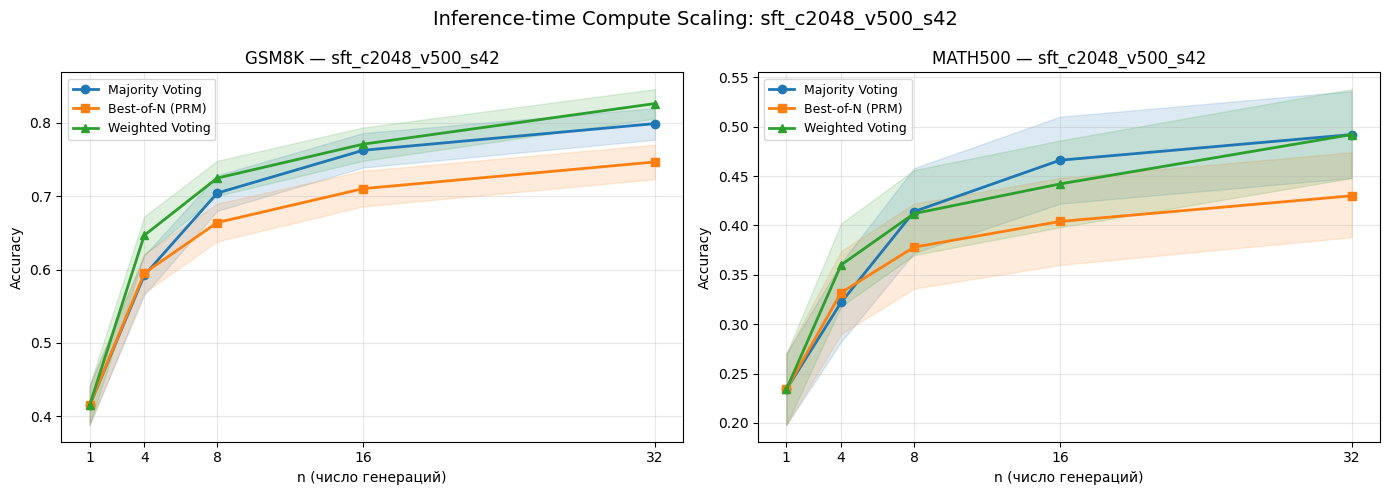

Графики сохранены ✓


In [19]:
import matplotlib.pyplot as plt

for model_name in all_generations:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, bench in zip(axes, ['gsm8k', 'math500']):
        for strat_name, strat_results, color, marker in [
            ('Majority Voting', mv_results, 'C0', 'o'),
            ('Best-of-N (PRM)', bon_results, 'C1', 's'),
            ('Weighted Voting', wv_results, 'C2', '^'),
        ]:
            data = strat_results.get(model_name, {}).get(bench, {})
            ns = sorted(data.keys())
            accs = [data[n]['accuracy'] for n in ns]
            ci_lo = [data[n]['ci'][0] for n in ns]
            ci_hi = [data[n]['ci'][1] for n in ns]
            ax.plot(ns, accs, f'-{marker}', color=color, label=strat_name, linewidth=2)
            ax.fill_between(ns, ci_lo, ci_hi, alpha=0.15, color=color)

        ax.set_xlabel('n (число генераций)')
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{bench.upper()} — {model_name}')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(N_VALUES)

    plt.suptitle(f'Inference-time Compute Scaling: {model_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{INFER_RESULTS}/{model_name}_accuracy_vs_n.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Графики сохранены ✓')

## Шаг 10. Итоговая проверка

In [20]:
del prm_model, prm_tokenizer
gc.collect()
torch.cuda.empty_cache()

checks = []
for model_name in all_generations:
    for bench in ['gsm8k', 'math500']:
        checks.append((f'{model_name}/{bench} генерации',
                        os.path.exists(f'{INFER_GENS}/{model_name}_{bench}_n{N_SAMPLES}.json')))
        checks.append((f'{model_name}/{bench} PRM scores',
                        os.path.exists(f'{INFER_SCORES}/{model_name}_{bench}_n{N_SAMPLES}_prm.json')))

checks.append(('inference_results.json',
                os.path.exists(f'{INFER_RESULTS}/inference_results.json')))

print('Итоговая проверка:')
all_ok = True
for name, ok in checks:
    print(f'  {"✓" if ok else "✗"} {name}')
    if not ok:
        all_ok = False

if all_ok:
    print('\n✓ Все артефакты на месте. 04_inference завершён.')
else:
    print('\n✗ Есть недостающие артефакты!')

Итоговая проверка:
  ✓ sft_c2048_v500_s42/gsm8k генерации
  ✓ sft_c2048_v500_s42/gsm8k PRM scores
  ✓ sft_c2048_v500_s42/math500 генерации
  ✓ sft_c2048_v500_s42/math500 PRM scores
  ✓ inference_results.json

✓ Все артефакты на месте. 04_inference завершён.
